In [2]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
train = pd.read_csv("../data/raw/train.csv")
test = pd.read_csv("../data/raw/test.csv")
store = pd.read_csv("../data/raw/store.csv")

/var/folders/vk/6pn68sk92z93wvsph2msbyvh0000gn/T/ipykernel_16125/4109812108.py:1: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("../data/raw/train.csv")


In [4]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Store shape:", store.shape)

Train shape: (1017209, 9)
Test shape: (41088, 8)
Store shape: (1115, 10)


In [5]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [6]:
print("TRAIN COLUMNS")
print(train.columns.tolist())

print("\nTEST COLUMNS")
print(test.columns.tolist())

print("\nSTORE COLUMNS")
print(store.columns.tolist())

TRAIN COLUMNS
['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']

TEST COLUMNS
['Id', 'Store', 'DayOfWeek', 'Date', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']

STORE COLUMNS
['Store', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']


In [7]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [8]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [9]:
print("Training period:")
print("Start:", train["Date"].min())
print("End:", train["Date"].max())

print("\nTesting period:")
print("Start:", test["Date"].min())
print("End:", test["Date"].max())

Training period:
Start: 2013-01-01
End: 2015-07-31

Testing period:
Start: 2015-08-01
End: 2015-09-17


In [10]:
print("Number of unique stores:", train["Store"].nunique())
print("Number of unique dates:", train["Date"].nunique())

Number of unique stores: 1115
Number of unique dates: 942


In [11]:
print("Missing values in train:")
print(train.isnull().sum())

print("\nMissing values in test:")
print(test.isnull().sum())

print("\nMissing values in store:")
print(store.isnull().sum())

Missing values in train:
Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

Missing values in test:
Id                0
Store             0
DayOfWeek         0
Date              0
Open             11
Promo             0
StateHoliday      0
SchoolHoliday     0
dtype: int64

Missing values in store:
Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64


In [12]:
print("Duplicate rows in train:", train.duplicated().sum())
print("Duplicate rows in test:", test.duplicated().sum())
print("Duplicate rows in store:", store.duplicated().sum())

Duplicate rows in train: 0
Duplicate rows in test: 0
Duplicate rows in store: 0


In [13]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  str   
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(1), str(1)
memory usage: 69.8+ MB


In [14]:
train["Sales"].describe()

count    1.017209e+06
mean     5.773819e+03
std      3.849926e+03
min      0.000000e+00
25%      3.727000e+03
50%      5.744000e+03
75%      7.856000e+03
max      4.155100e+04
Name: Sales, dtype: float64

In [15]:
print("Stores with zero sales:", (train["Sales"] == 0).sum())
print("Closed store observations:", (train["Open"] == 0).sum())

Stores with zero sales: 172871
Closed store observations: 172817


In [16]:
print(train["StateHoliday"].value_counts())
print("\nPromo:")
print(train["Promo"].value_counts())

print("\nOpen:")
print(train["Open"].value_counts())

StateHoliday
0    855087
0    131072
a     20260
b      6690
c      4100
Name: count, dtype: int64

Promo:
Promo
0    629129
1    388080
Name: count, dtype: int64

Open:
Open
1    844392
0    172817
Name: count, dtype: int64


In [17]:
zero_sales_open = train[
    (train["Sales"] == 0) & (train["Open"] == 1)
]

print("Open stores with zero sales:", len(zero_sales_open))
zero_sales_open.head()

Open stores with zero sales: 54


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
86825,971,5,2015-05-15,0,0,1,0,0,1
142278,674,4,2015-03-26,0,0,1,0,0,0
196938,699,4,2015-02-05,0,0,1,1,0,0
322053,708,3,2014-10-01,0,0,1,1,0,0
330176,357,1,2014-09-22,0,0,1,0,0,0


## Initial Dataset Observations

- The training dataset contains 1,017,209 observations across 1,115 stores.
- Historical training data covers January 2013 to July 2015.
- The test period covers August 2015 to September 2015.
- The target variable is `Sales`, representing daily store sales.
- Average daily sales are approximately 5,774, with a maximum observed value of 41,551.
- There are no duplicate rows in the train, test, or store datasets.
- The training dataset contains no missing values.
- The test dataset contains 11 missing values in the `Open` column.
- The store dataset contains missing values related to Promo2 information.
- Most zero-sales observations correspond to stores that were closed.
- 54 observations have `Open = 1` but both `Sales = 0` and `Customers = 0`; these will be investigated rather than automatically removed.
- Promotions are active in a substantial portion of store-day observations.

In [18]:
print("Train data types:")
print(train.dtypes)

print("\nStore data types:")
print(store.dtypes)

Train data types:
Store             int64
DayOfWeek         int64
Date                str
Sales             int64
Customers         int64
Open              int64
Promo             int64
StateHoliday     object
SchoolHoliday     int64
dtype: object

Store data types:
Store                          int64
StoreType                        str
Assortment                       str
CompetitionDistance          float64
CompetitionOpenSinceMonth    float64
CompetitionOpenSinceYear     float64
Promo2                         int64
Promo2SinceWeek              float64
Promo2SinceYear              float64
PromoInterval                    str
dtype: object


In [19]:
train["StateHoliday"].value_counts(dropna=False)

StateHoliday
0    855087
0    131072
a     20260
b      6690
c      4100
Name: count, dtype: int64

In [20]:
train_clean["StateHoliday"].value_counts()

NameError: name 'train_clean' is not defined

In [21]:
train_clean = train.copy()
test_clean = test.copy()
store_clean = store.copy()

In [22]:
train_clean["StateHoliday"] = train_clean["StateHoliday"].astype(str)
test_clean["StateHoliday"] = test_clean["StateHoliday"].astype(str)

In [23]:
train_clean["StateHoliday"].value_counts()

StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: int64

In [24]:
train_clean["Date"] = pd.to_datetime(train_clean["Date"])
test_clean["Date"] = pd.to_datetime(test_clean["Date"])

In [25]:
print(train_clean["Date"].dtype)
print(test_clean["Date"].dtype)

datetime64[us]
datetime64[us]


In [26]:
print("Train date range:", train_clean["Date"].min(), "to", train_clean["Date"].max())
print("Test date range:", test_clean["Date"].min(), "to", test_clean["Date"].max())

Train date range: 2013-01-01 00:00:00 to 2015-07-31 00:00:00
Test date range: 2015-08-01 00:00:00 to 2015-09-17 00:00:00


In [27]:
missing_open = test_clean[test_clean["Open"].isna()]

print("Number of missing Open values:", len(missing_open))
missing_open

Number of missing Open values: 11


,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
479,480,622,4,2015-09-17,NaN,1,0,0
1335,1336,622,3,2015-09-16,NaN,1,0,0
2191,2192,622,2,2015-09-15,NaN,1,0,0
3047,3048,622,1,2015-09-14,NaN,1,0,0
4759,4760,622,6,2015-09-12,NaN,0,0,0
5615,5616,622,5,2015-09-11,NaN,0,0,0
6471,6472,622,4,2015-09-10,NaN,0,0,0
7327,7328,622,3,2015-09-09,NaN,0,0,0
8183,8184,622,2,2015-09-08,NaN,0,0,0
9039,9040,622,1,2015-09-07,NaN,0,0,0


In [28]:
print(missing_open[["Store", "Date", "DayOfWeek", "Promo",
                     "StateHoliday", "SchoolHoliday"]])

       Store       Date  DayOfWeek  Promo StateHoliday  SchoolHoliday
479      622 2015-09-17          4      1            0              0
1335     622 2015-09-16          3      1            0              0
2191     622 2015-09-15          2      1            0              0
3047     622 2015-09-14          1      1            0              0
4759     622 2015-09-12          6      0            0              0
5615     622 2015-09-11          5      0            0              0
6471     622 2015-09-10          4      0            0              0
7327     622 2015-09-09          3      0            0              0
8183     622 2015-09-08          2      0            0              0
9039     622 2015-09-07          1      0            0              0
10751    622 2015-09-05          6      0            0              0


In [29]:
store_622_history = train_clean[
    train_clean["Store"] == 622
].sort_values("Date")

store_622_history.tail(30)[
    ["Date", "DayOfWeek", "Sales", "Customers", "Open", "Promo"]
]

,Date,DayOfWeek,Sales,Customers,Open,Promo
32956,2015-07-02,4,5732,521,1,1
31841,2015-07-03,5,5637,501,1,1
30726,2015-07-04,6,3221,319,1,0
29611,2015-07-05,7,0,0,0,0
28496,2015-07-06,1,4516,453,1,0
27381,2015-07-07,2,3642,405,1,0
26266,2015-07-08,3,4042,406,1,0
25151,2015-07-09,4,4788,477,1,0
24036,2015-07-10,5,4493,478,1,0
22921,2015-07-11,6,2511,281,1,0


In [30]:
print("Store 622 historical Open distribution:")
print(store_622_history["Open"].value_counts())

print("\nStore 622 last training date:")
print(store_622_history["Date"].max())

Store 622 historical Open distribution:
Open
1    784
0    158
Name: count, dtype: int64

Store 622 last training date:
2015-07-31 00:00:00


In [31]:
print(
    store_622_history.groupby("DayOfWeek")["Open"]
    .agg(["count", "sum"])
)

           count  sum
DayOfWeek            
1            134  128
2            135  134
3            135  132
4            135  127
5            135  129
6            134  134
7            134    0


In [32]:
print(
    store_622_history.groupby("DayOfWeek")["Open"]
    .mean()
)

DayOfWeek
1    0.955224
2    0.992593
3    0.977778
4    0.940741
5    0.955556
6    1.000000
7    0.000000
Name: Open, dtype: float64


In [33]:
test_clean.loc[test_clean["Open"].isna(), "Open"] = 1

In [34]:
print("Missing Open values after cleaning:",
      test_clean["Open"].isna().sum())

Missing Open values after cleaning: 0


### Handling Missing `Open` Values

The test dataset contained 11 missing values in the `Open` column.

All 11 missing observations belonged to Store 622 and occurred from September 5–17, 2015. Historical analysis of Store 622 showed that it was consistently closed on Sundays and generally operated from Monday through Saturday.

The missing observations occurred only from Monday through Saturday and were not associated with state or school holidays.

Based on this historical weekday operating pattern, the 11 missing `Open` values were filled with `1` (open).

In [35]:
store_clean.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [36]:
store_clean[store_clean["Promo2"] == 0][
    ["Promo2", "Promo2SinceWeek", "Promo2SinceYear", "PromoInterval"]
].head(10)

,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,0,NaN,NaN,NaN
3,0,NaN,NaN,NaN
4,0,NaN,NaN,NaN
5,0,NaN,NaN,NaN
6,0,NaN,NaN,NaN
7,0,NaN,NaN,NaN
8,0,NaN,NaN,NaN
9,0,NaN,NaN,NaN
15,0,NaN,NaN,NaN
22,0,NaN,NaN,NaN


In [37]:
print("Stores not participating in Promo2:",
      (store_clean["Promo2"] == 0).sum())

print("Stores participating in Promo2:",
      (store_clean["Promo2"] == 1).sum())

Stores not participating in Promo2: 544
Stores participating in Promo2: 571


In [38]:
print(
    store_clean.groupby("Promo2")[
        ["Promo2SinceWeek", "Promo2SinceYear", "PromoInterval"]
    ].apply(lambda x: x.isnull().sum())
)

        Promo2SinceWeek  Promo2SinceYear  PromoInterval
Promo2                                                 
0                   544              544            544
1                     0                0              0


In [39]:
# Handle non-applicable Promo2 information
store_clean.loc[store_clean["Promo2"] == 0, "Promo2SinceWeek"] = 0
store_clean.loc[store_clean["Promo2"] == 0, "Promo2SinceYear"] = 0
store_clean.loc[store_clean["Promo2"] == 0, "PromoInterval"] = "None"

print("Missing values after Promo2 cleaning:")
print(store_clean.isnull().sum())

Missing values after Promo2 cleaning:
Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek                0
Promo2SinceYear                0
PromoInterval                  0
dtype: int64


In [40]:
missing_distance = store_clean[
    store_clean["CompetitionDistance"].isna()
]

missing_distance

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
290,291,d,a,NaN,NaN,NaN,0,0.0,0.0,None
621,622,a,c,NaN,NaN,NaN,0,0.0,0.0,None
878,879,d,a,NaN,NaN,NaN,1,5.0,2013.0,"Feb,May,Aug,Nov"


In [41]:
print(missing_distance[[
    "Store",
    "StoreType",
    "CompetitionDistance",
    "CompetitionOpenSinceMonth",
    "CompetitionOpenSinceYear"
]])

     Store StoreType  CompetitionDistance  CompetitionOpenSinceMonth  \
290    291         d                  NaN                        NaN   
621    622         a                  NaN                        NaN   
878    879         d                  NaN                        NaN   

     CompetitionOpenSinceYear  
290                       NaN  
621                       NaN  
878                       NaN  


In [42]:
median_distance = store_clean["CompetitionDistance"].median()

store_clean["CompetitionDistance"] = (
    store_clean["CompetitionDistance"].fillna(median_distance)
)

print("Median CompetitionDistance:", median_distance)
print("Missing CompetitionDistance:",
      store_clean["CompetitionDistance"].isna().sum())

Median CompetitionDistance: 2325.0
Missing CompetitionDistance: 0


In [43]:
missing_competition_date = store_clean[
    store_clean["CompetitionOpenSinceMonth"].isna()
]

print("Stores with missing competition opening date:",
      len(missing_competition_date))

print("\nPromo2 distribution:")
print(missing_competition_date["Promo2"].value_counts())

print("\nCompetition distance statistics:")
print(missing_competition_date["CompetitionDistance"].describe())

Stores with missing competition opening date: 354

Promo2 distribution:
Promo2
1    206
0    148
Name: count, dtype: int64

Competition distance statistics:
count      354.000000
mean      5404.533898
std       7381.042192
min         20.000000
25%        647.500000
50%       2425.000000
75%       7877.500000
max      75860.000000
Name: CompetitionDistance, dtype: float64


In [44]:
missing_competition_date[
    ["Store", "StoreType", "CompetitionDistance",
     "CompetitionOpenSinceMonth", "CompetitionOpenSinceYear"]
].head(20)

,Store,StoreType,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear
11,12,a,1070.0,NaN,NaN
12,13,d,310.0,NaN,NaN
15,16,a,3270.0,NaN,NaN
18,19,a,3240.0,NaN,NaN
21,22,a,1040.0,NaN,NaN
25,26,d,2300.0,NaN,NaN
28,29,d,2170.0,NaN,NaN
31,32,a,2910.0,NaN,NaN
39,40,a,180.0,NaN,NaN
40,41,d,1180.0,NaN,NaN


In [45]:
# Create an indicator for missing competition opening dates
store_clean["CompetitionOpenDateMissing"] = (
    store_clean["CompetitionOpenSinceMonth"].isna().astype(int)
)

print(
    "Stores with unknown competition opening date:",
    store_clean["CompetitionOpenDateMissing"].sum()
)

Stores with unknown competition opening date: 354


In [46]:
# Fill unknown competition opening dates with 0
store_clean["CompetitionOpenSinceMonth"] = (
    store_clean["CompetitionOpenSinceMonth"].fillna(0)
)

store_clean["CompetitionOpenSinceYear"] = (
    store_clean["CompetitionOpenSinceYear"].fillna(0)
)

In [47]:
print("Missing values after competition cleaning:")
print(store_clean.isnull().sum())

Missing values after competition cleaning:
Store                         0
StoreType                     0
Assortment                    0
CompetitionDistance           0
CompetitionOpenSinceMonth     0
CompetitionOpenSinceYear      0
Promo2                        0
Promo2SinceWeek               0
Promo2SinceYear               0
PromoInterval                 0
CompetitionOpenDateMissing    0
dtype: int64


In [48]:
store_clean["CompetitionDistanceMissing"] = (
    store_clean["Store"].isin(missing_distance["Store"]).astype(int)
)

print(
    "Originally missing CompetitionDistance:",
    store_clean["CompetitionDistanceMissing"].sum()
)

Originally missing CompetitionDistance: 3


## 3. Exploratory Data Analysis

### 3.1 Overall Sales Trend

In [49]:
# Aggregate total sales by date
daily_sales = (
    train_clean
    .groupby("Date")["Sales"]
    .sum()
    .reset_index()
)

daily_sales.head()

,Date,Sales
0,2013-01-01,97235
1,2013-01-02,6949829
2,2013-01-03,6347820
3,2013-01-04,6638954
4,2013-01-05,5951593


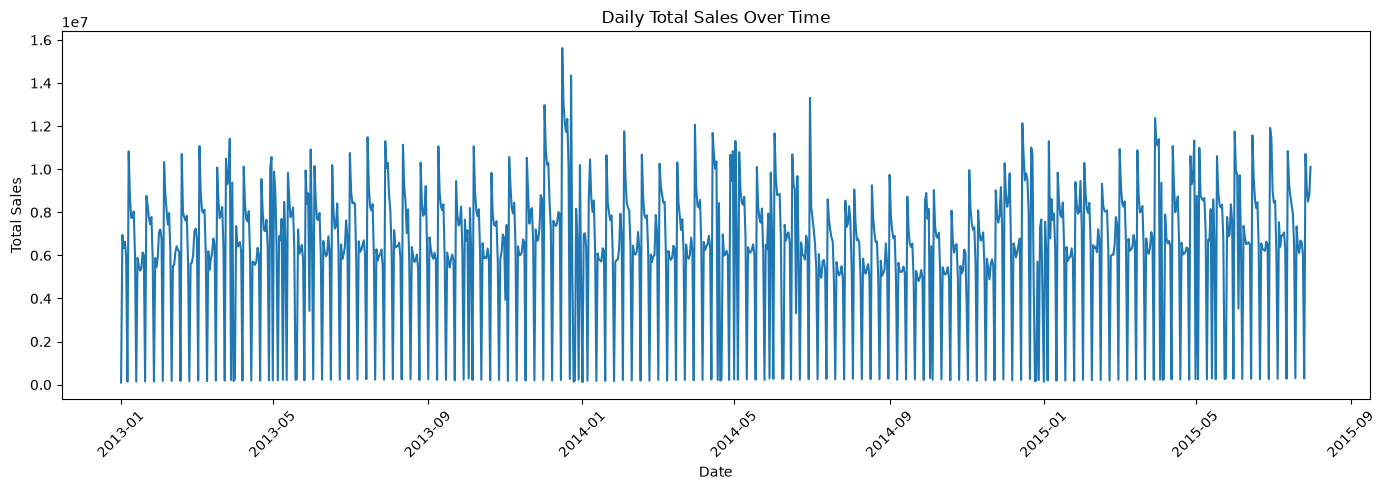

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    daily_sales["Date"],
    daily_sales["Sales"]
)

plt.title("Daily Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.2 Sales Trend for Open Stores

Since closed stores have zero sales, the overall daily sales series contains artificial drops.
We therefore analyze sales from open stores separately to better understand the underlying demand pattern.

In [51]:
# Sales from open stores only
open_sales = train_clean[train_clean["Open"] == 1]

daily_open_sales = (
    open_sales
    .groupby("Date")["Sales"]
    .sum()
    .reset_index()
)

daily_open_sales.head()

,Date,Sales
0,2013-01-01,97235
1,2013-01-02,6949829
2,2013-01-03,6347820
3,2013-01-04,6638954
4,2013-01-05,5951593


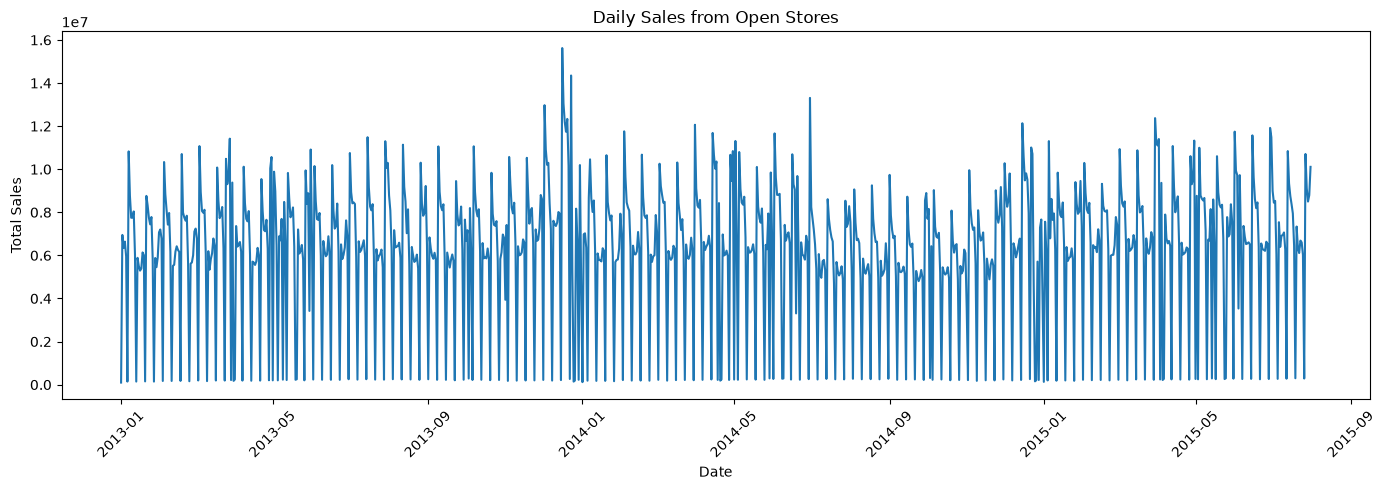

In [52]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_open_sales["Date"],
    daily_open_sales["Sales"]
)

plt.title("Daily Sales from Open Stores")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 3.3 Seven-Day Rolling Average

A 7-day rolling average is used to smooth daily fluctuations and reveal the underlying sales trend while reducing the effect of weekly variation.

In [53]:
# Calculate 7-day rolling average
daily_open_sales["Rolling_7_Day"] = (
    daily_open_sales["Sales"]
    .rolling(window=7)
    .mean()
)

daily_open_sales.head(10)

,Date,Sales,Rolling_7_Day
0,2013-01-01,97235,NaN
1,2013-01-02,6949829,NaN
2,2013-01-03,6347820,NaN
3,2013-01-04,6638954,NaN
4,2013-01-05,5951593,NaN
5,2013-01-06,143904,NaN
6,2013-01-07,10826848,5.279455e+06
7,2013-01-08,8749437,6.515484e+06
8,2013-01-09,7746603,6.629308e+06
9,2013-01-10,7751485,6.829832e+06


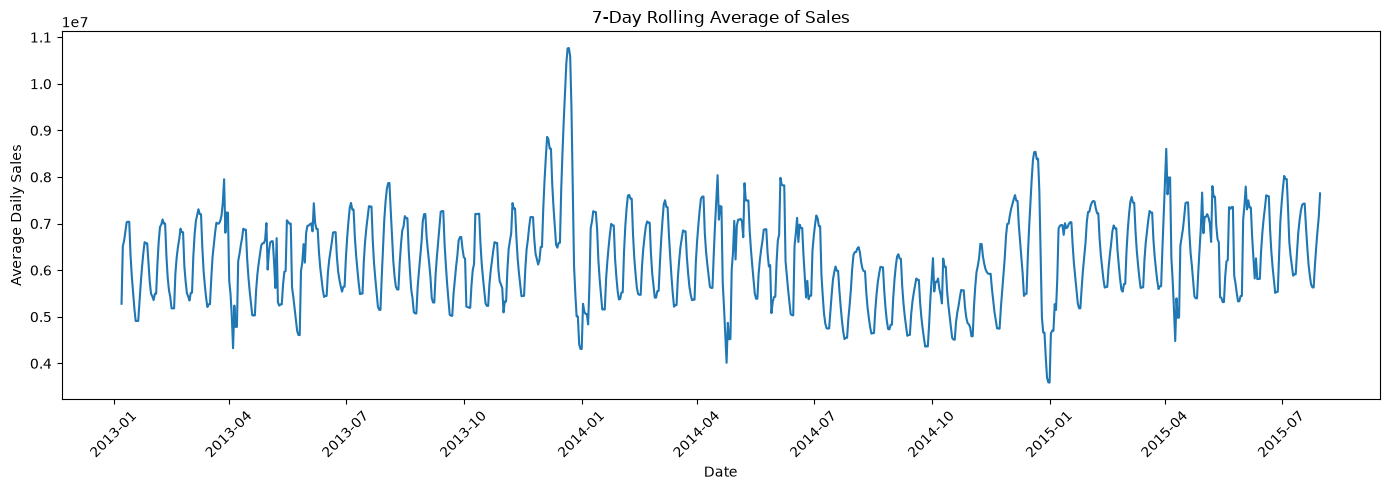

In [54]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_open_sales["Date"],
    daily_open_sales["Rolling_7_Day"]
)

plt.title("7-Day Rolling Average of Sales")
plt.xlabel("Date")
plt.ylabel("Average Daily Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 3.4 Monthly Sales Pattern

Monthly aggregation is used to identify longer-term trends and seasonal variations in store demand.

In [55]:
# Create monthly sales totals
monthly_sales = (
    open_sales
    .set_index("Date")
    .resample("ME")["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Date,Sales
0,2013-01-31,180132207
1,2013-02-28,171534275
2,2013-03-31,201180369
3,2013-04-30,183431432
4,2013-05-31,185411063


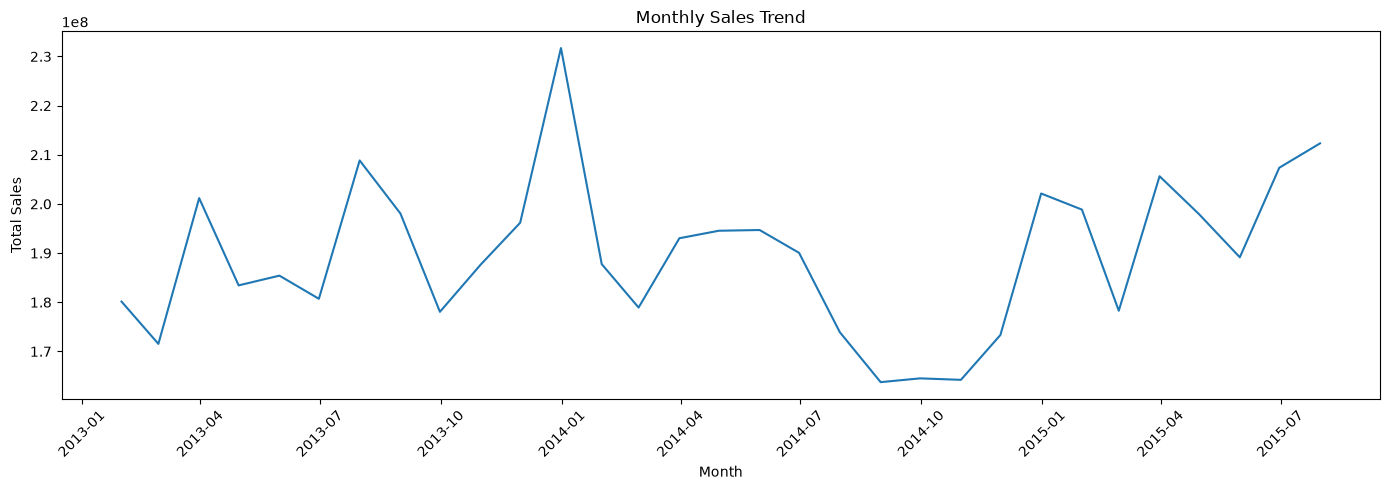

In [56]:
plt.figure(figsize=(14, 5))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Sales"]
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Monthly Sales Analysis – Observations

The monthly sales analysis shows considerable variation in demand over time. 
A strong peak is observed around January 2014, followed by a decline during 
mid-to-late 2014. Sales recover toward the end of 2014 and remain relatively 
strong during 2015.

These recurring changes indicate the presence of seasonal patterns and 
time-dependent demand, making time-series forecasting techniques suitable 
for this dataset.

In [57]:
day_sales = (
    open_sales
    .groupby("DayOfWeek")["Sales"]
    .mean()
)

day_sales

DayOfWeek
1    8216.073074
2    7088.113656
3    6728.122978
4    6767.310159
5    7072.677012
6    5874.840238
7    8224.723908
Name: Sales, dtype: float64

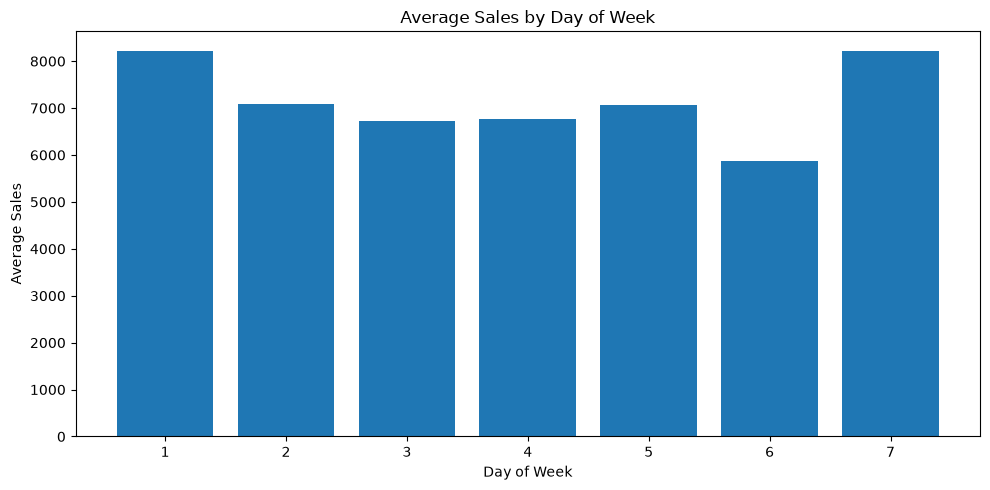

In [58]:
plt.figure(figsize=(10, 5))

plt.bar(
    day_sales.index,
    day_sales.values
)

plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.xticks(range(1, 8))

plt.tight_layout()
plt.show()

### Day-of-Week Sales Analysis – Observations

Average sales vary considerably across the days of the week, indicating a
strong weekly seasonal pattern. Monday records relatively high average sales,
while sales generally decline toward Saturday. Sunday also shows high average
sales among stores that remain open, but this value should be interpreted
carefully because many stores are closed on Sundays.

The variation across weekdays confirms that DayOfWeek is an important feature
for demand forecasting.

In [59]:
promo_sales = (
    open_sales
    .groupby("Promo")["Sales"]
    .mean()
)

print(promo_sales)

Promo
0    5929.407603
1    8228.281239
Name: Sales, dtype: float64


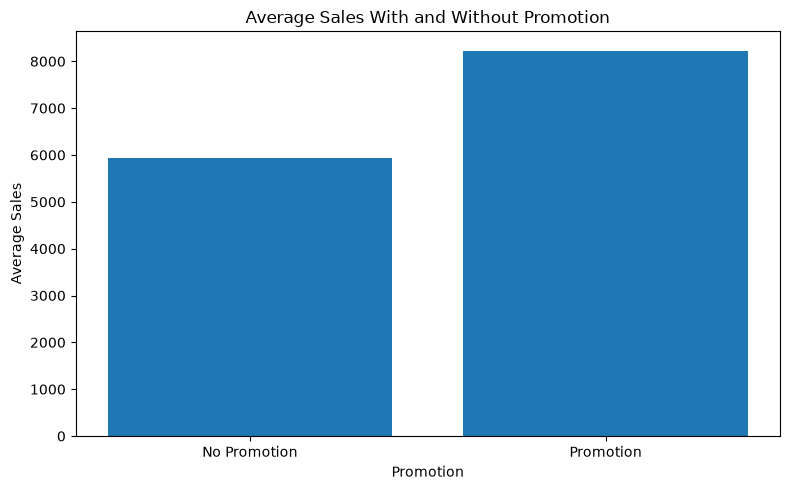

In [60]:
plt.figure(figsize=(8, 5))

plt.bar(
    ["No Promotion", "Promotion"],
    promo_sales.values
)

plt.title("Average Sales With and Without Promotion")
plt.xlabel("Promotion")
plt.ylabel("Average Sales")

plt.tight_layout()
plt.show()

### Promotion Analysis – Observations

The analysis shows a clear difference in average sales between promotional
and non-promotional days. Stores operating with a promotion have considerably
higher average sales than stores without a promotion.

This indicates that promotional activity is an important factor associated
with store demand. However, the difference may also be influenced by other
factors such as day of week, seasonality, store characteristics, and holidays.
Therefore, Promo will be retained as an important feature for forecasting.

In [61]:
store_type_sales = (
    train_clean
    .merge(
        store_clean[["Store", "StoreType"]],
        on="Store",
        how="left"
    )
    .query("Open == 1")
    .groupby("StoreType")["Sales"]
    .mean()
)

print(store_type_sales)

StoreType
a     6925.167661
b    10231.407505
c     6932.512755
d     6822.141881
Name: Sales, dtype: float64


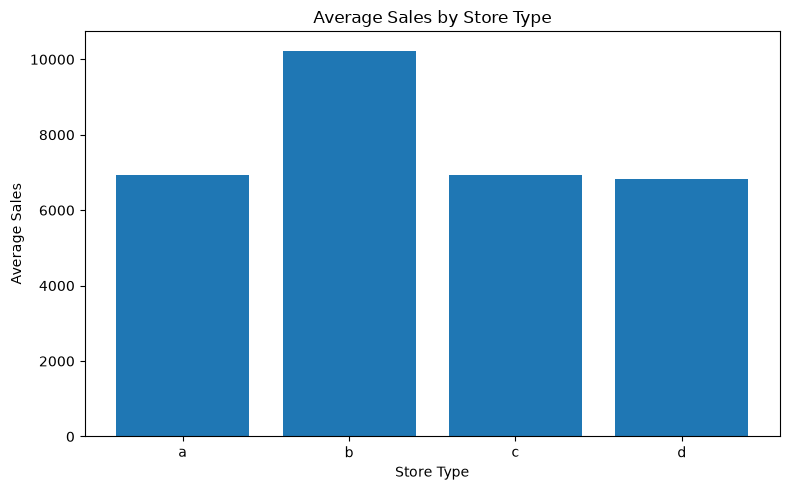

In [62]:
plt.figure(figsize=(8, 5))

plt.bar(
    store_type_sales.index,
    store_type_sales.values
)

plt.title("Average Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Average Sales")

plt.tight_layout()
plt.show()

### Store Type Analysis – Observations

Average sales vary significantly across different store types. Store Type B
has the highest average sales, while Store Types A, C, and D have relatively
similar but lower average sales.

This indicates that store type captures important differences in store
performance and customer demand. Therefore, StoreType will be retained as an
important feature for demand forecasting.

In [63]:
assortment_sales = (
    train_clean
    .merge(
        store_clean[["Store", "Assortment"]],
        on="Store",
        how="left"
    )
    .query("Open == 1")
    .groupby("Assortment")["Sales"]
    .mean()
)

print(assortment_sales)

Assortment
a    6621.017039
b    8639.346322
c    7300.526339
Name: Sales, dtype: float64


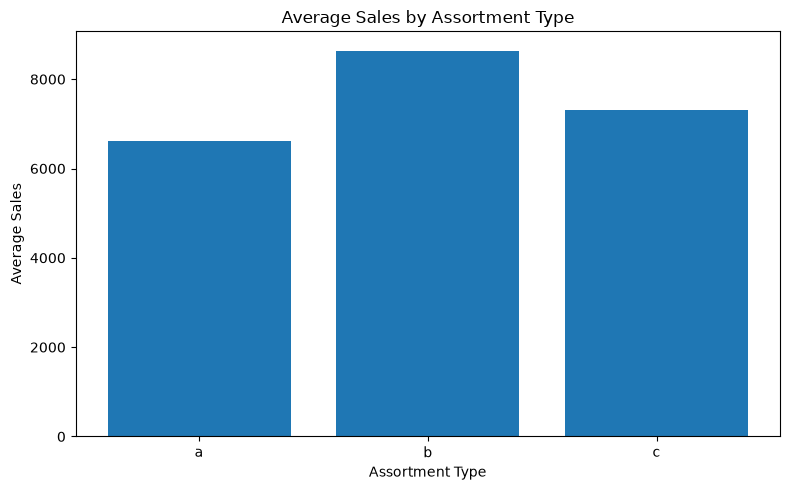

In [64]:
plt.figure(figsize=(8, 5))

plt.bar(
    assortment_sales.index,
    assortment_sales.values
)

plt.title("Average Sales by Assortment Type")
plt.xlabel("Assortment Type")
plt.ylabel("Average Sales")

plt.tight_layout()
plt.show()

### Assortment Analysis – Observations

Average sales differ across the three assortment types. Assortment B records
the highest average sales, followed by Assortment C, while Assortment A has
the lowest average sales.

This indicates that assortment type captures differences in store demand and
can provide useful information for the forecasting model. Therefore,
Assortment will be retained as a feature.

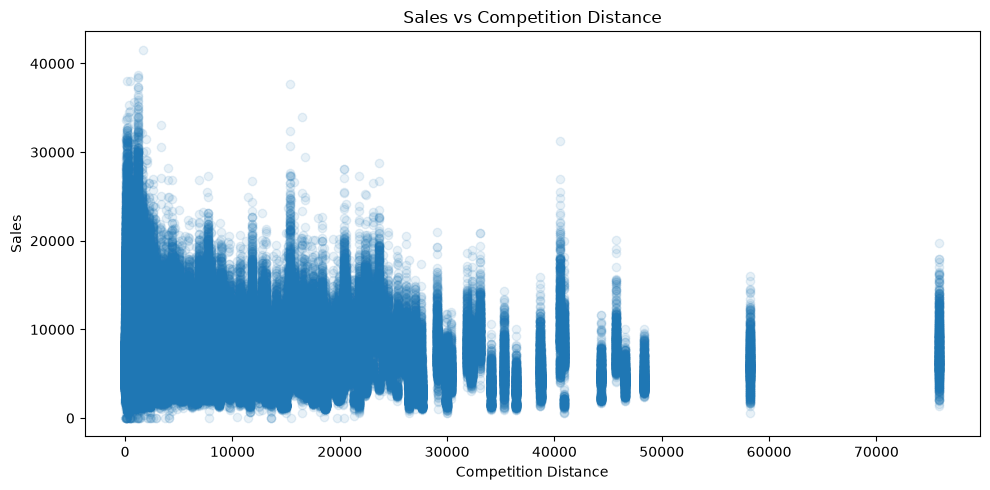

In [65]:
competition_sales = (
    train_clean
    .merge(
        store_clean[["Store", "CompetitionDistance"]],
        on="Store",
        how="left"
    )
    .query("Open == 1")
)

plt.figure(figsize=(10, 5))

plt.scatter(
    competition_sales["CompetitionDistance"],
    competition_sales["Sales"],
    alpha=0.1
)

plt.title("Sales vs Competition Distance")
plt.xlabel("Competition Distance")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

### Competition Distance Analysis – Observations

The scatter plot does not show a simple linear relationship between competition
distance and sales. Sales vary considerably across different competition
distances, particularly for stores with nearby competitors.

This suggests that competition distance alone does not determine store sales.
Other factors such as store type, promotions, day of week, and seasonality may
also have a significant influence. CompetitionDistance will therefore be
retained as a feature for the forecasting model.

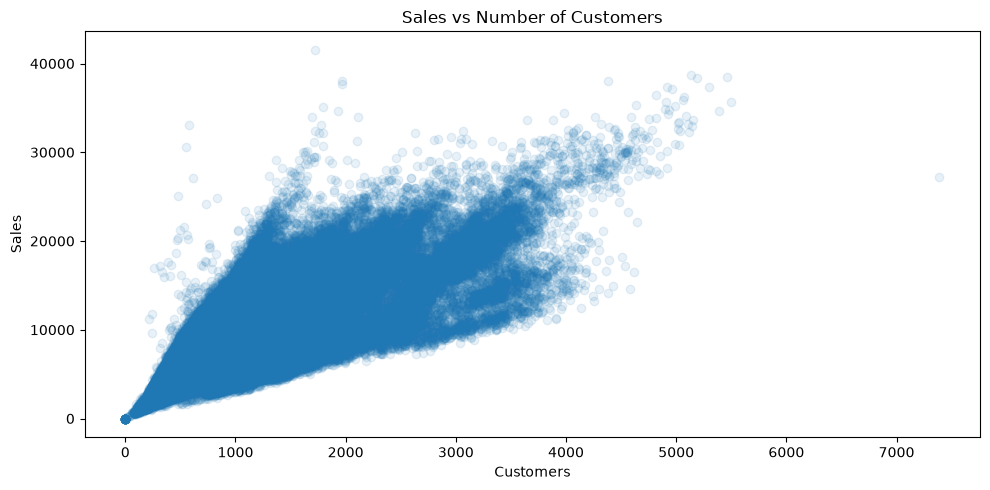

In [66]:
customer_sales = train_clean[train_clean["Open"] == 1]

plt.figure(figsize=(10, 5))

plt.scatter(
    customer_sales["Customers"],
    customer_sales["Sales"],
    alpha=0.1
)

plt.title("Sales vs Number of Customers")
plt.xlabel("Customers")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

In [67]:
print(
    "Correlation between Customers and Sales:",
    customer_sales["Customers"].corr(customer_sales["Sales"])
)

Correlation between Customers and Sales: 0.8235967321975464


### Sales vs Customers – Observations

The scatter plot shows a strong positive relationship between the number of
customers and sales. The correlation coefficient is approximately 0.824,
indicating a strong positive correlation.

As the number of customers increases, sales generally increase. However, the
relationship is not perfectly linear, suggesting that other factors such as
promotions, store type, day of week, and seasonality also influence sales.

Customers is therefore an important feature for predicting sales.